In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Input
from tensorflow.keras.utils import plot_model
from IPython.display import Image

2025-03-25 06:33:43.638497: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742880823.650370  105631 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742880823.653929  105631 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742880823.664335  105631 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1742880823.664350  105631 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1742880823.664351  105631 computation_placer.cc:177] computation placer alr

In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
X_train = pd.read_csv('x_train.csv')
X_test = pd.read_csv('x_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

In [4]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=[X_train.shape[1]]),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1742880825.325265  105631 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [6]:
# Plot the model architecture (if pydot is installed)
try:
    plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
    Image('model_architecture.png')
    print("Model Summary:")
    model.summary()
except Exception as e:
    print(f"Could not generate model architecture visualization: {e}")

Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,641 (33.75 KB)

 Trainable params: 8,641 (33.75 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the model
history = model.fit(
    X_train, y_train['price'],
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 23.4896 - mae: 3.3862 - val_loss: 1.0389 - val_mae: 0.7907
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.5097 - mae: 0.9222 - val_loss: 1.1898 - val_mae: 1.0014
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6824 - mae: 0.6755 - val_loss: 0.2245 - val_mae: 0.3959
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3095 - mae: 0.4190 - val_loss: 0.1713 - val_mae: 0.3251
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1885 - mae: 0.3221 - val_loss: 0.1653 - val_mae: 0.3258
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1797 - mae: 0.2878 - val_loss: 0.1705 - val_mae: 0.3337
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1530 - mae: 0.2716 - val_loss: 0.1636 - val_mae: 0.3310
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1939 - mae: 0.2963 - val_loss: 0.1638 - val_mae: 0.3328
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1131 - mae:

In [18]:
# Test the model and print the results
loss, mae = model.evaluate(X_test, y_test['price'], verbose=0)
print("Mean Absolute Error on test data: ", mae)
print("Model Accuracy: ", 100-mae)
print("R2 Score: ", 1 - loss)

Mean Absolute Error on test data:  0.2284138947725296
Model Accuracy:  99.77158610522747
R2 Score:  0.8574974536895752


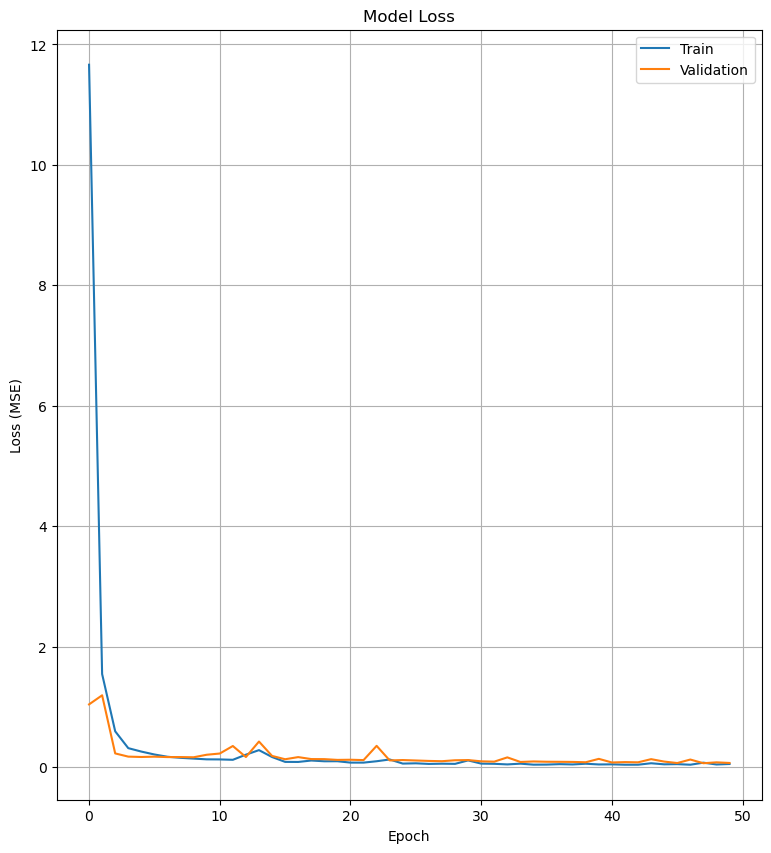

In [9]:
# Plot training history
plt.figure(figsize=(20, 10))

# Plot training & validation loss values
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'])
    plt.legend(['Train', 'Validation'], loc='upper right')
else:
    plt.legend(['Train'], loc='upper right')
plt.title('Model Loss')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.grid(True)

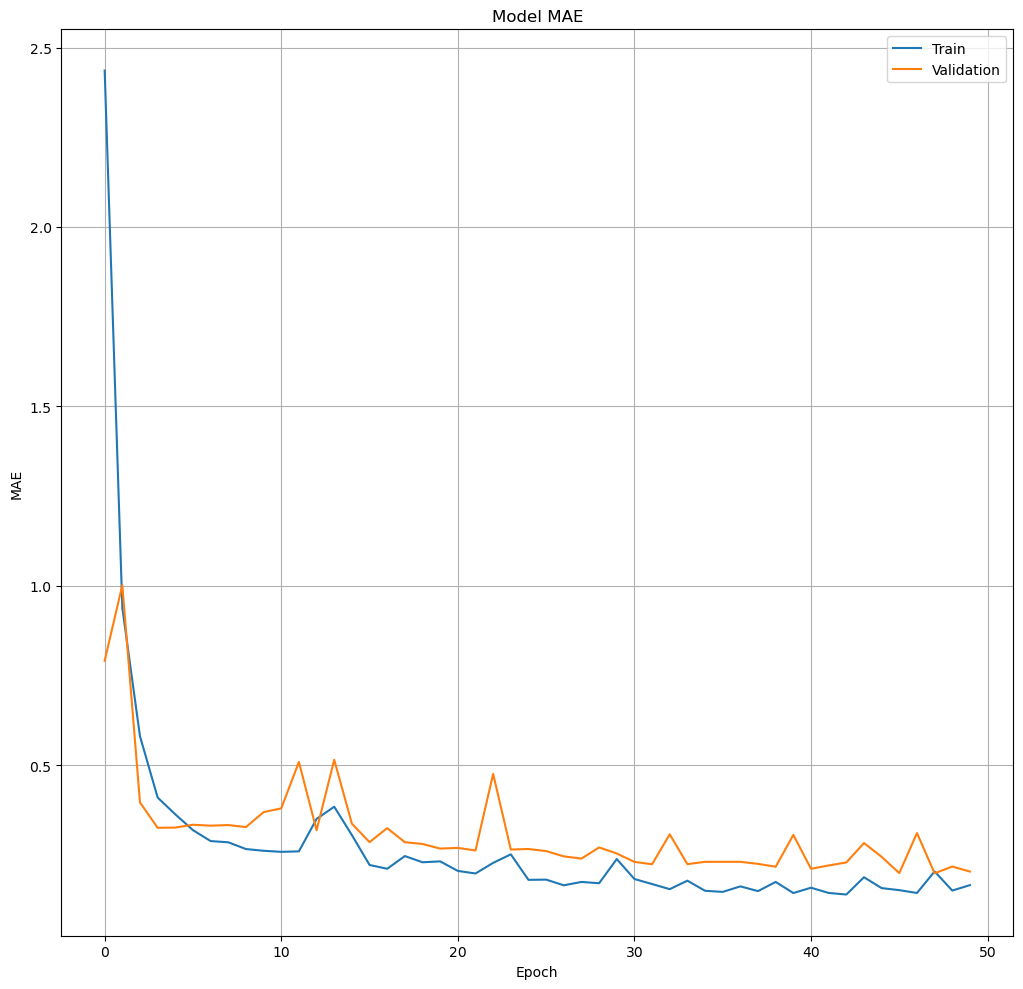

In [10]:
# Plot training history
plt.figure(figsize=(20, 10))

# Plot training & validation mean absolute error
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'])
if 'val_mae' in history.history:
    plt.plot(history.history['val_mae'])
    plt.legend(['Train', 'Validation'], loc='upper right')
else:
    plt.legend(['Train'], loc='upper right')
plt.title('Model MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.grid(True)
plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


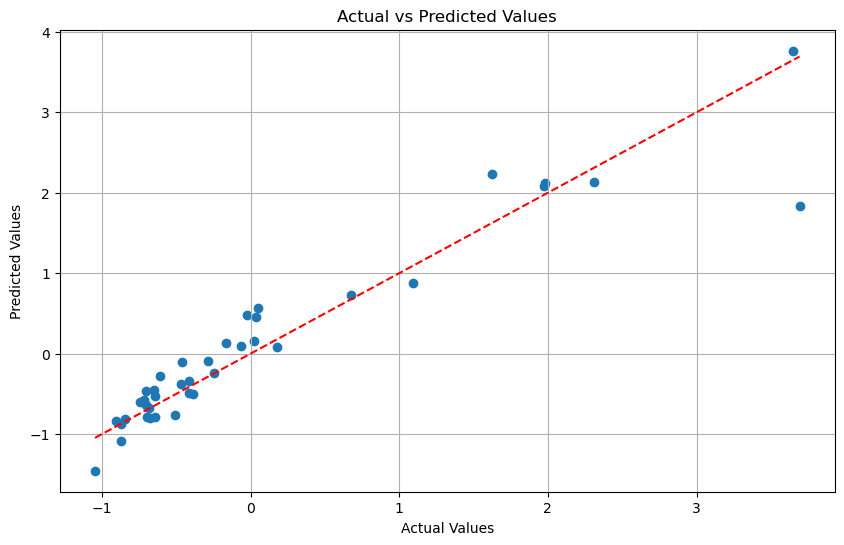

In [11]:
# Predicted vs Actual values
y_pred = model.predict(X_test)
y_true = y_test['price'].values

plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
# Add diagonal line for perfect predictions
diagonal = np.linspace(min(y_true), max(y_true), 100)
plt.plot(diagonal, diagonal, 'r--')
plt.grid(True)
plt.show()

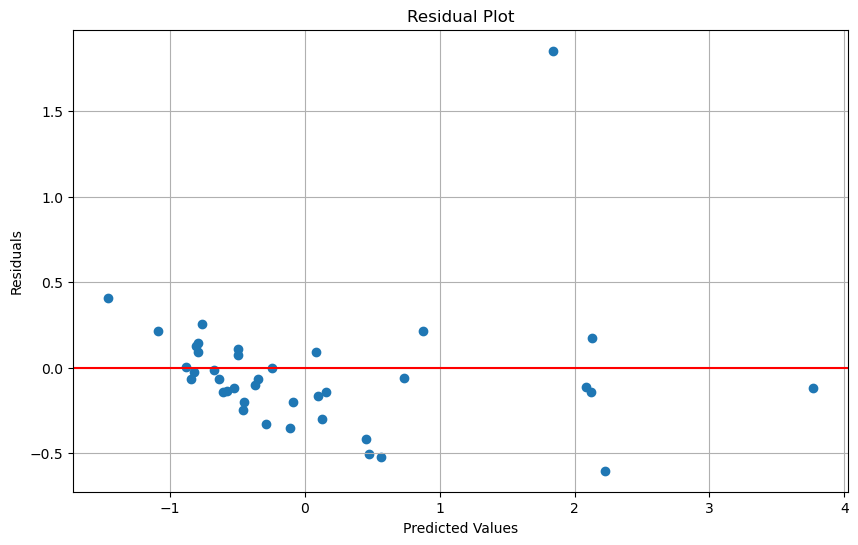

In [12]:
# Residual Plot
residuals = y_true - y_pred.flatten()

plt.figure(figsize=(10, 6))
plt.scatter(y_pred.flatten(), residuals)
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

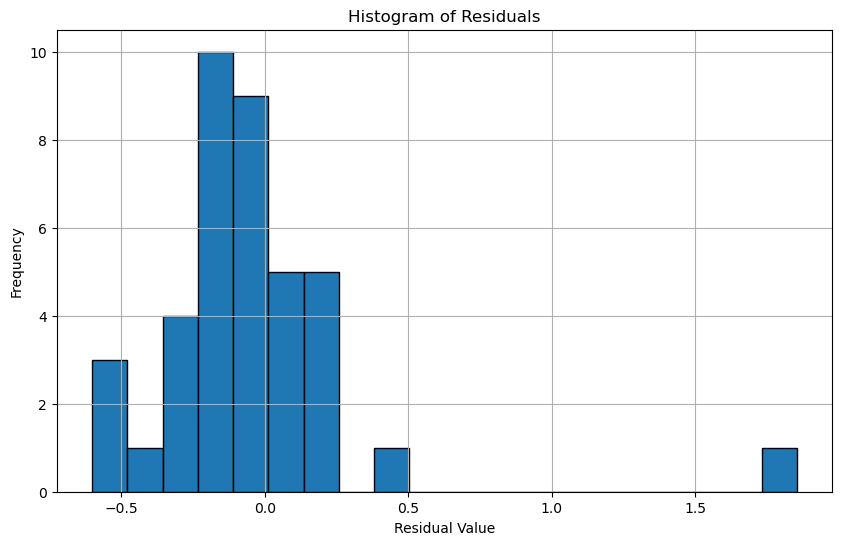

In [13]:
# Histogram of residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=20, edgecolor='black')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.grid(True)
plt.show()


In [14]:
# Overfitting Check
train_pred = model.predict(X_train)
train_mae = np.mean(np.abs(train_pred.flatten() - y_train['price'].values))
test_mae = mae  # Using the test MAE we already have

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [17]:
print(f"Training MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Difference: {abs(train_mae - test_mae):.4f}")
print(f"Ratio (Test/Train): {test_mae / train_mae:.4f}")

if test_mae / train_mae > 1.2 and test_mae - train_mae > 0.1:
    print("⚠️ Warning: Test error is significantly higher than training error (>20% difference)")
    print("This suggests the model may be overfitting to the training data.")
    print("Consider: adding regularization, reducing model complexity, or gathering more data.")
else:
    print("✓ No strong evidence of overfitting based on error comparison.")

Training MAE: 0.1430
Test MAE: 0.2284
Difference: 0.0854
Ratio (Test/Train): 1.5974
✓ No strong evidence of overfitting based on error comparison.


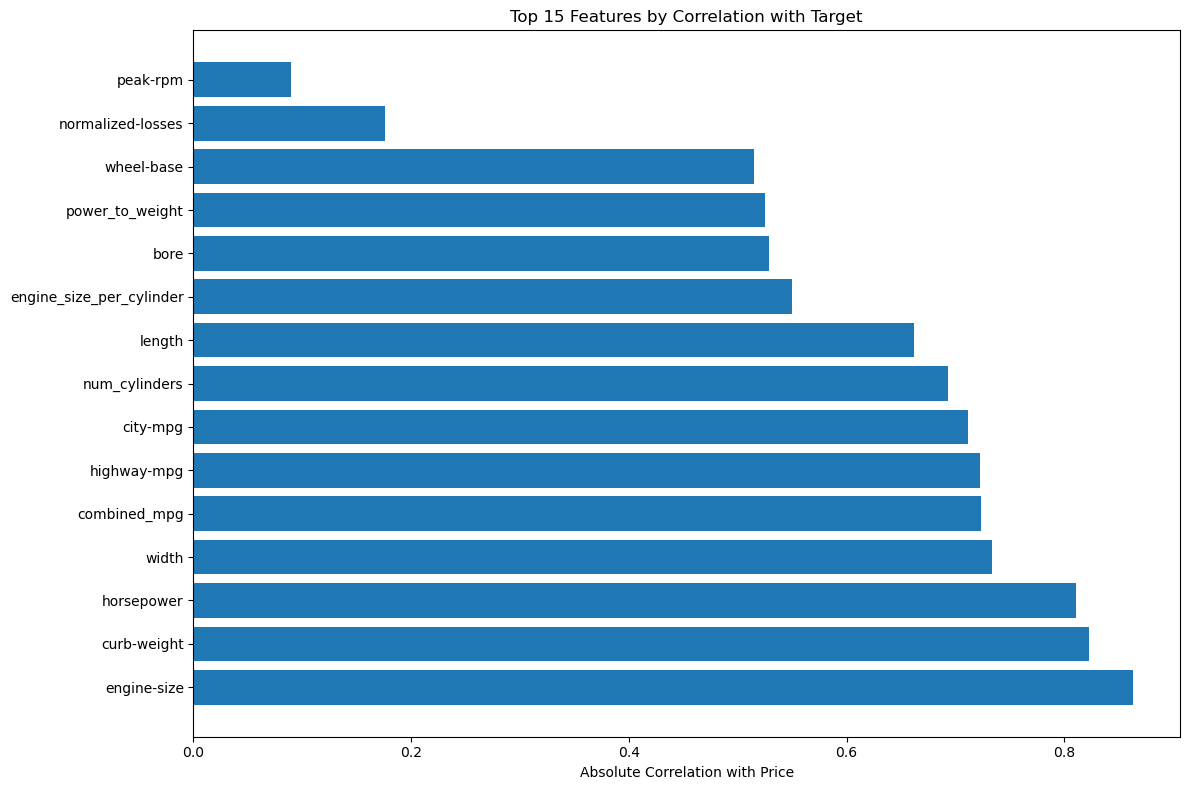

In [16]:
# Feature importance visualization (using correlation)
feature_importance = []
for col in X_train.select_dtypes(include=[np.number]).columns:
    corr = np.corrcoef(X_train[col], y_train['price'])[0, 1]
    feature_importance.append((col, abs(corr)))
    
# Sort and plot top 15 features
feature_importance.sort(key=lambda x: x[1], reverse=True)
top_features = feature_importance[:15]
plt.figure(figsize=(12, 8))
plt.barh([x[0] for x in top_features], [x[1] for x in top_features])
plt.xlabel('Absolute Correlation with Price')
plt.title('Top 15 Features by Correlation with Target')
plt.tight_layout()
plt.show()